In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('google.csv')

In [3]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [4]:
import matplotlib.pyplot as plt

In [23]:
df=df.sort_values('Year')

In [24]:
df['Last Updated']=df['Last Updated'].replace({'1.0.19':'January 1, 2018'})

In [25]:
df['Last Updated']=pd.to_datetime(df['Last Updated'])

In [26]:
df['Year']=df['Last Updated'].dt.year
df['Year']

7479     2010
9908     2011
7487     2011
1544     2011
10282    2011
         ... 
10837    2018
2        2018
1        2018
10840    2018
0        2018
Name: Year, Length: 10841, dtype: int32

In [27]:
df['Rating']=df['Rating'].astype(float)

In [28]:
group_years=df.groupby('Year')
year_avg_rating=group_years['Rating'].mean()
year_avg_rating

Year
2010    4.200000
2011    3.966667
2012    3.785714
2013    4.073404
2014    4.037895
2015    4.067268
2016    4.041782
2017    4.094793
2018    4.246797
Name: Rating, dtype: float64

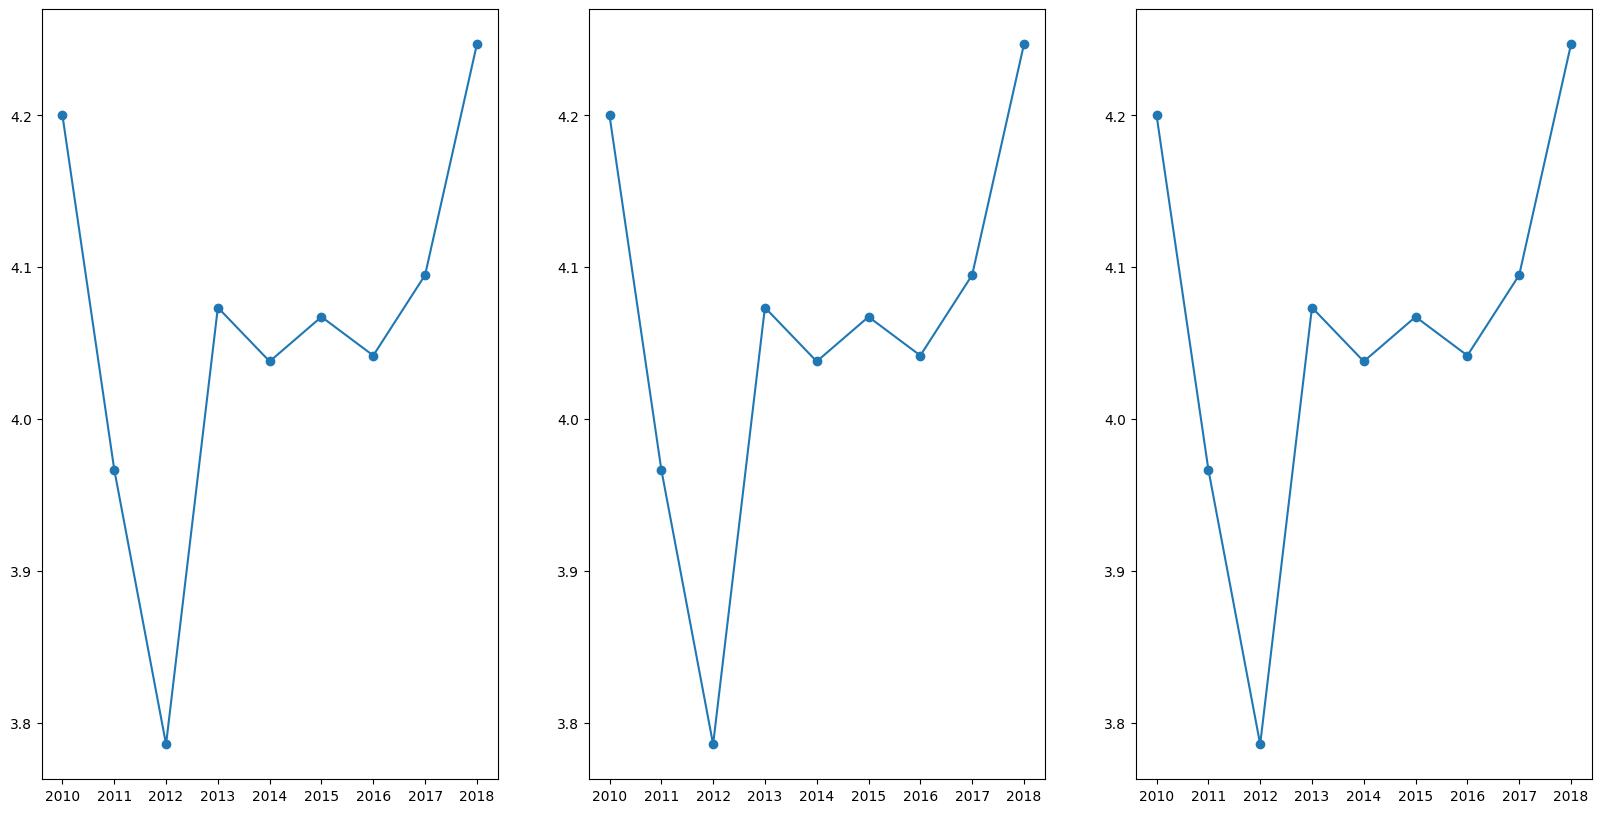

In [29]:
#subplot

fig,ax=plt.subplots(1,3,figsize=(20,10)) 
#rows=1,col=3

ax[0].plot(year_avg_rating,marker='o')
ax[1].plot(year_avg_rating,marker='o')
ax[2].plot(year_avg_rating,marker='o')
#ax[3].plot(year_avg_rating,marker='o') - we get error

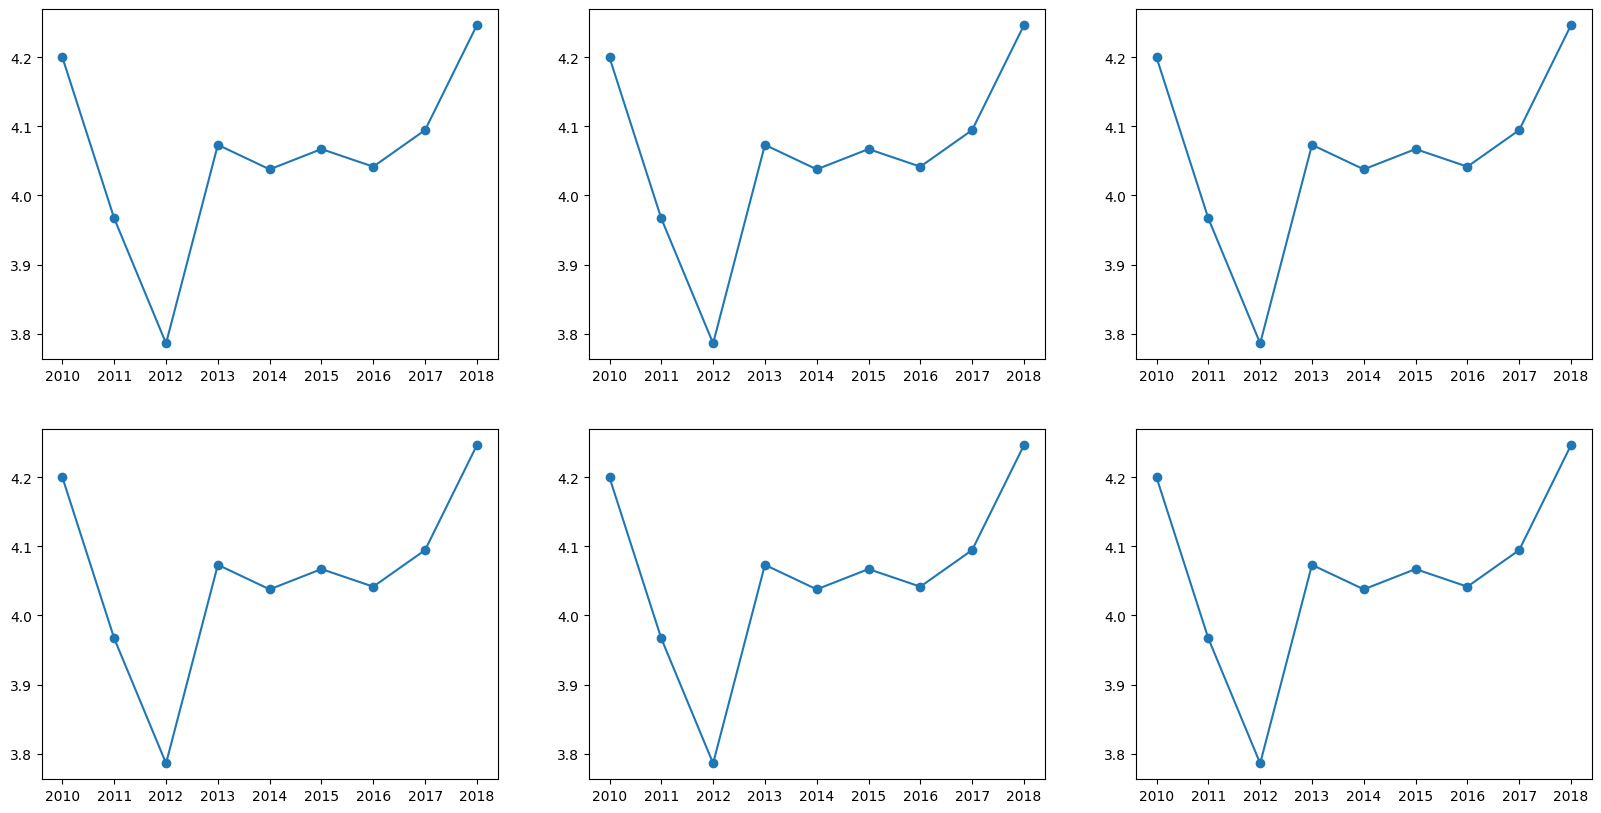

In [ ]:
# using matplotlib
fig,ax=plt.subplots(2,3,figsize=(20,10)) 
#rows=1,col=3

ax[0,0].plot(year_avg_rating,marker='o')
ax[0,1].plot(year_avg_rating,marker='o')
ax[0,2].plot(year_avg_rating,marker='o')
ax[1,0].plot(year_avg_rating,marker='o')
ax[1,1].plot(year_avg_rating,marker='o')
ax[1,2].plot(year_avg_rating,marker='o')

In [31]:
df['Price']=df['Price'].str.removeprefix('$')
df['Price']=df['Price'].replace({'Everyone':None})
df['Price']=df['Price'].astype(float)

In [32]:
import seaborn as sns

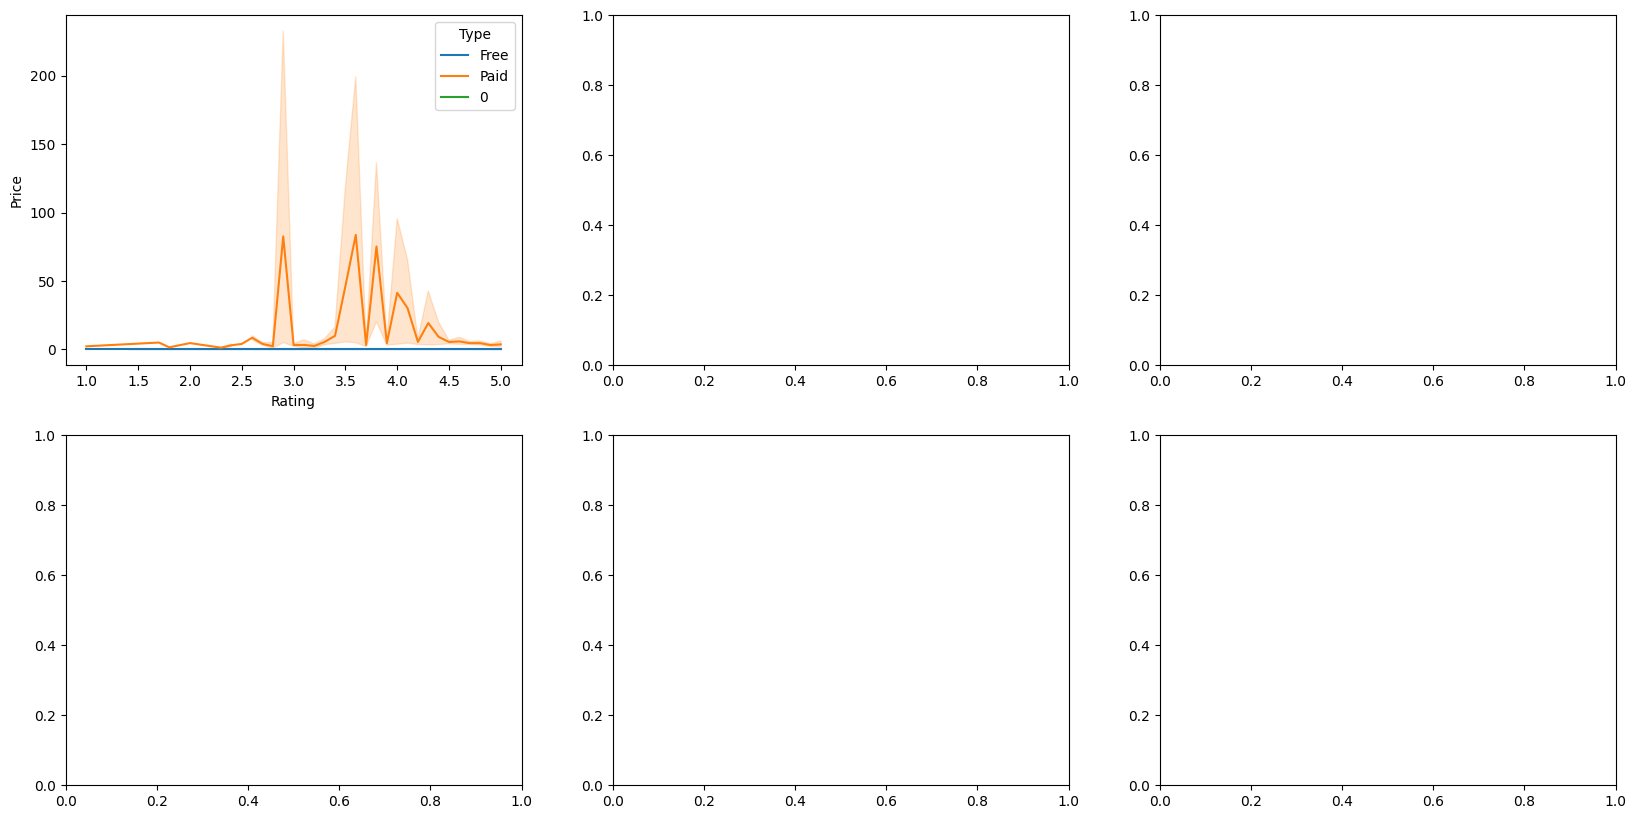

In [34]:
#using seaborn
fig,ax=plt.subplots(2,3,figsize=(20,10)) 

sns.lineplot(x='Rating',y='Price',data=df,hue='Type',ax=ax[0,0])

#to save the graph in jpg format using fig

fig.savefig('output.png') #.jpg  | .jpeg